In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [3]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np


X = np.random.rand(1000, 10)  
y = np.random.rand(1000, 1)   


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = Sequential()


model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer
model.add(Dense(units=32, activation='relu'))

# Output layer
model.add(Dense(units=1))


model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

model.summary()


D:\ml ENN\my_venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Model training
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1734 - val_loss: 0.1317
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1055 - val_loss: 0.1013
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0918 - val_loss: 0.0999
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0939 - val_loss: 0.1004
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0895 - val_loss: 0.0970
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0855 - val_loss: 0.0945
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0895 - val_loss: 0.0948
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0862 - val_loss: 0.0939
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0862 - val_loss: 0.0941
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0844 - val_loss: 0.1006
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0826 - val_loss: 0.0862
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

In [19]:
#  predictions
y_pred_ann = model.predict(X_test)

# Evaluating the model
mae_ann = mean_absolute_error(y_test, y_pred_ann)
mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = mean_squared_error(y_test, y_pred_ann, squared=False)

print(f'ANN Mean Absolute Error: {mae_ann}')
print(f'ANN Mean Squared Error: {mse_ann}')
print(f'ANN Root Mean Squared Error: {rmse_ann}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
ANN Mean Absolute Error: 0.2611590521566761
ANN Mean Squared Error: 0.10015256242884671
ANN Root Mean Squared Error: 0.31646889646353354


D:\ml ENN\my_venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [20]:
!pip install matplotlib


In [21]:
import sys
print(sys.executable)


D:\ml ENN\my_venv\Scripts\python.exe


In [22]:
import matplotlib.pyplot as plt


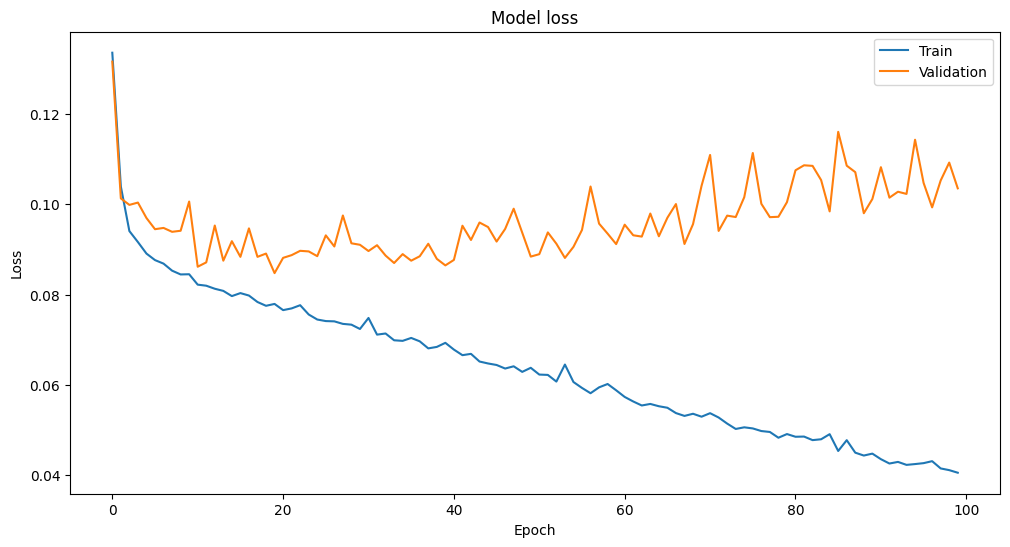

In [23]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


In [24]:
!pip install seaborn


In [25]:
import seaborn as sns


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import joblib


In [27]:

file_path = 'datasetenergy.csv'  
data = pd.read_csv(file_path)

In [28]:

data_cleaned = data.dropna(axis=1, how='all')


irrelevant_columns = ['Unnamed: 16', 'cp', 'hp', 'c-cp', 'cp-c', 'h-hp', 'hp-h', 'c er2', 'h er2', 'mre', 'Unnamed: 28']
data_cleaned = data_cleaned.drop(columns=irrelevant_columns)

data_cleaned = data_cleaned.dropna()


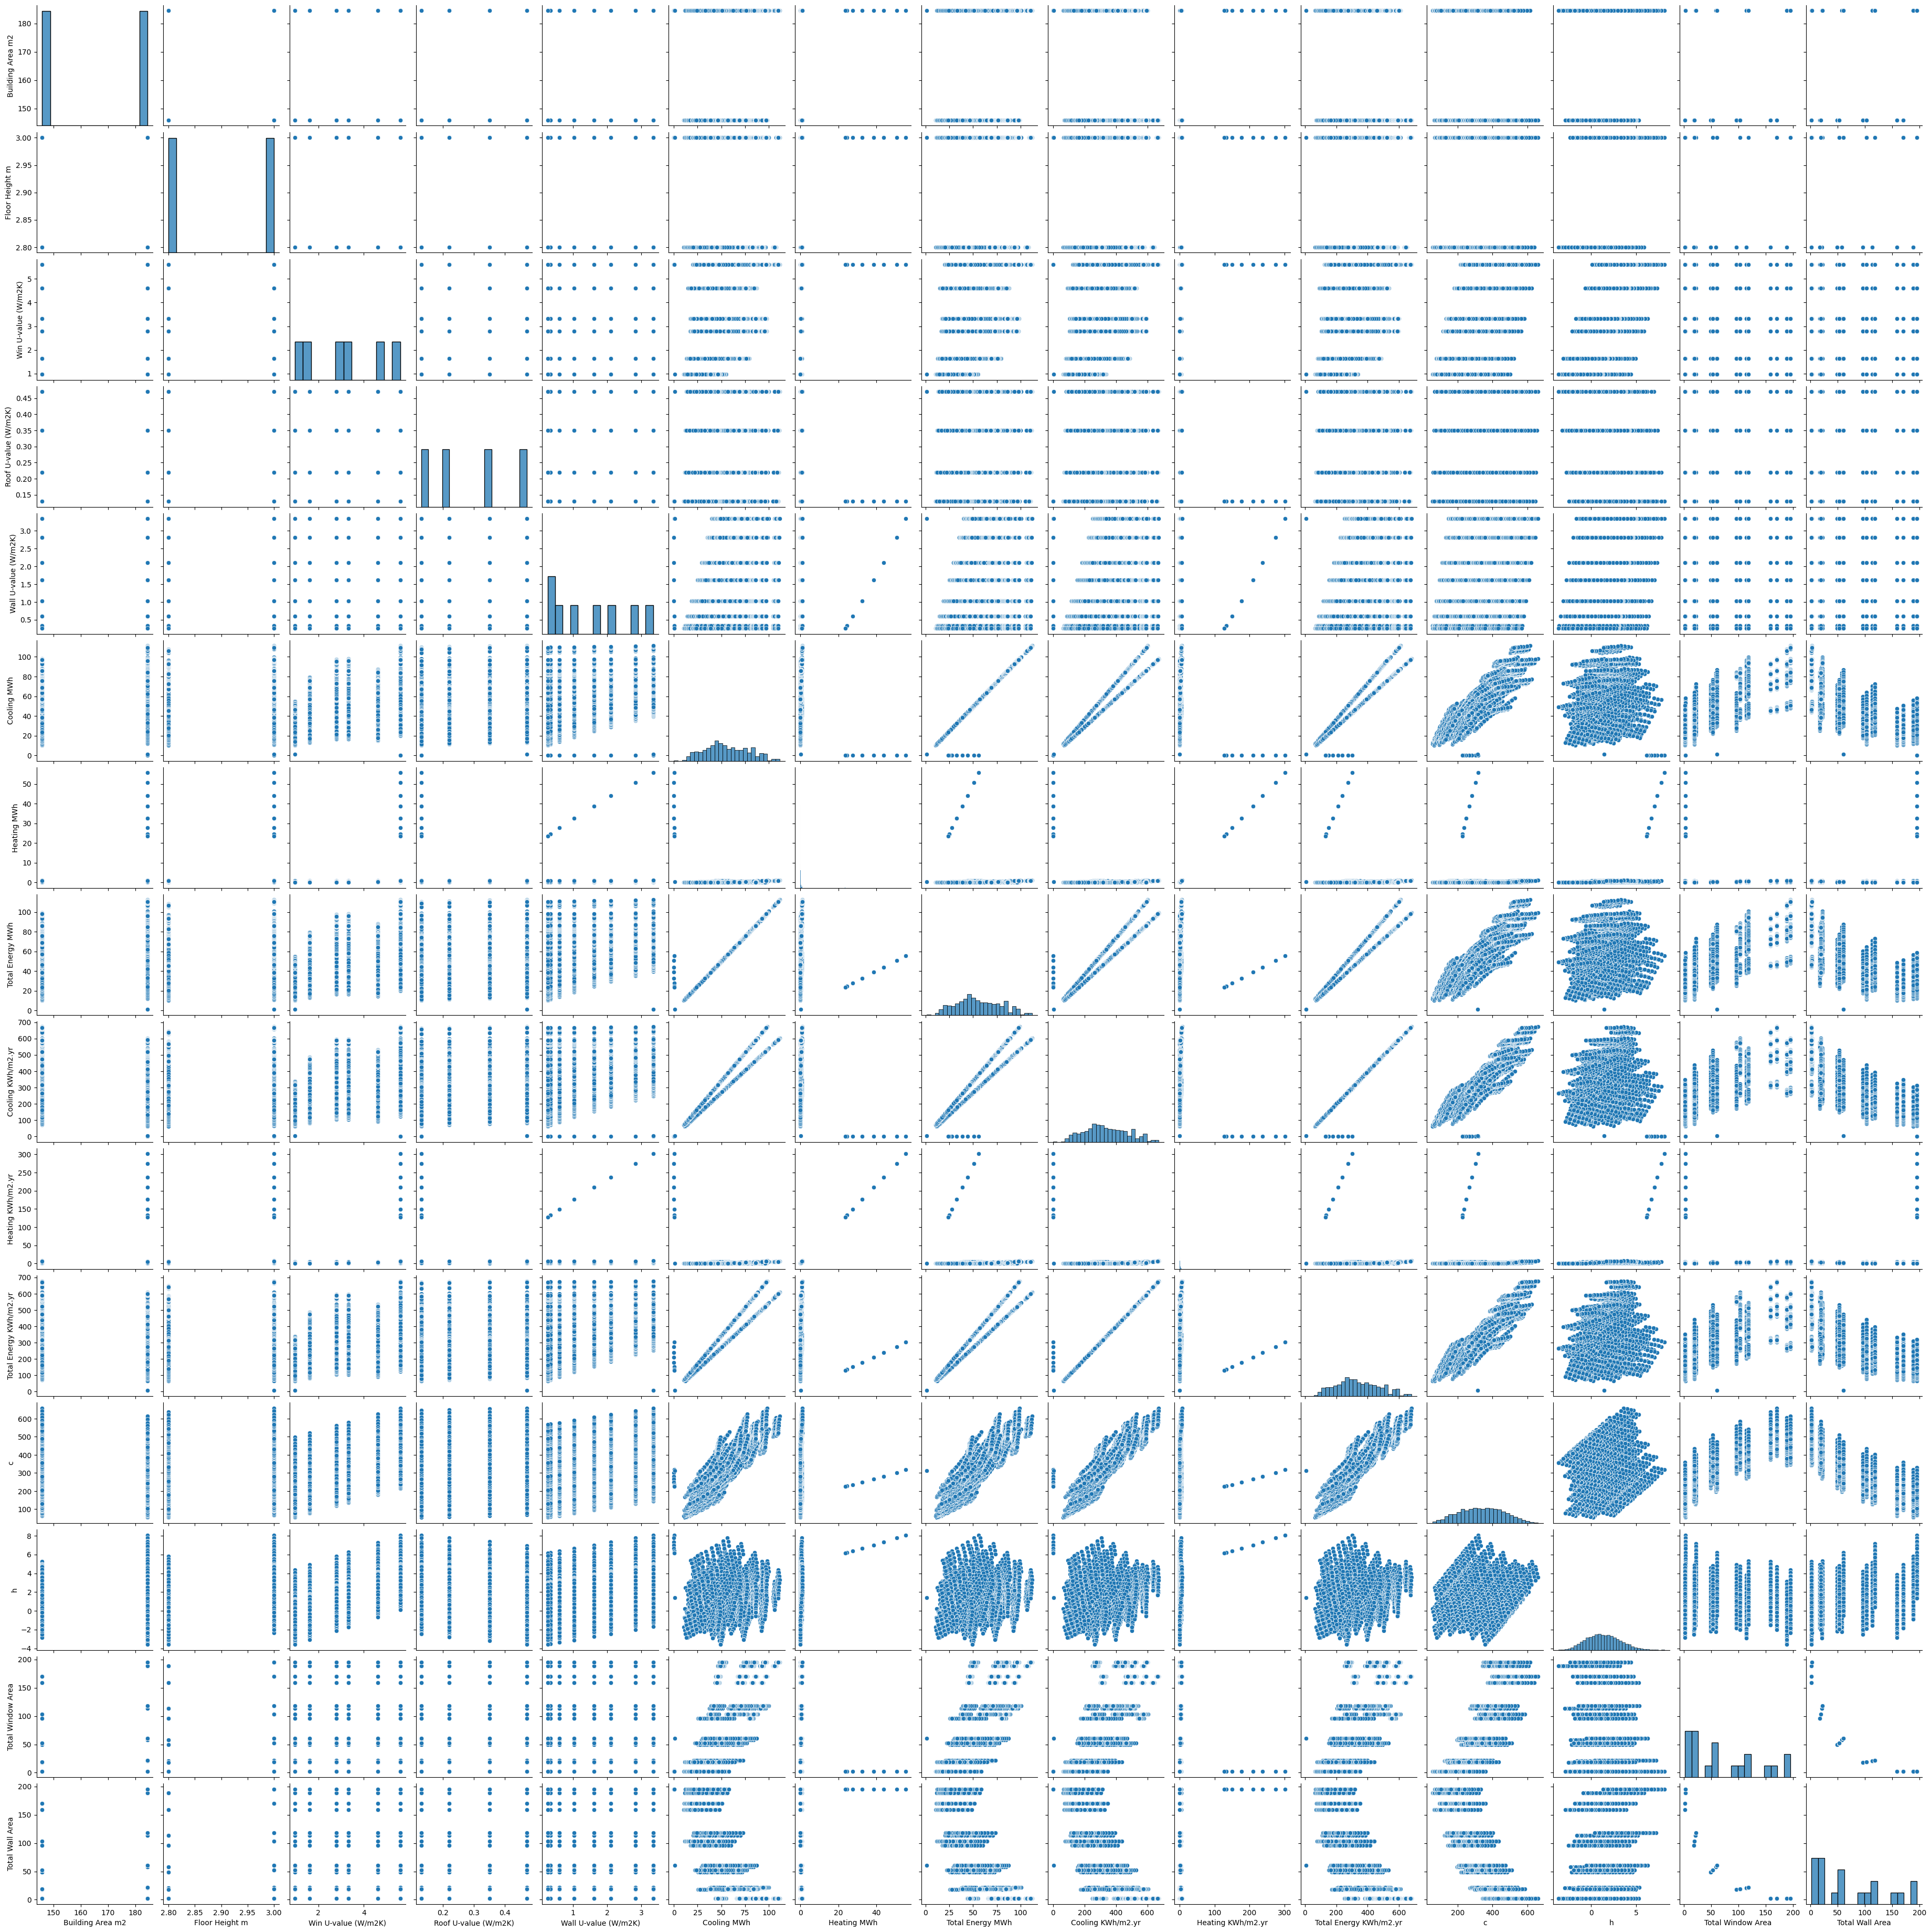

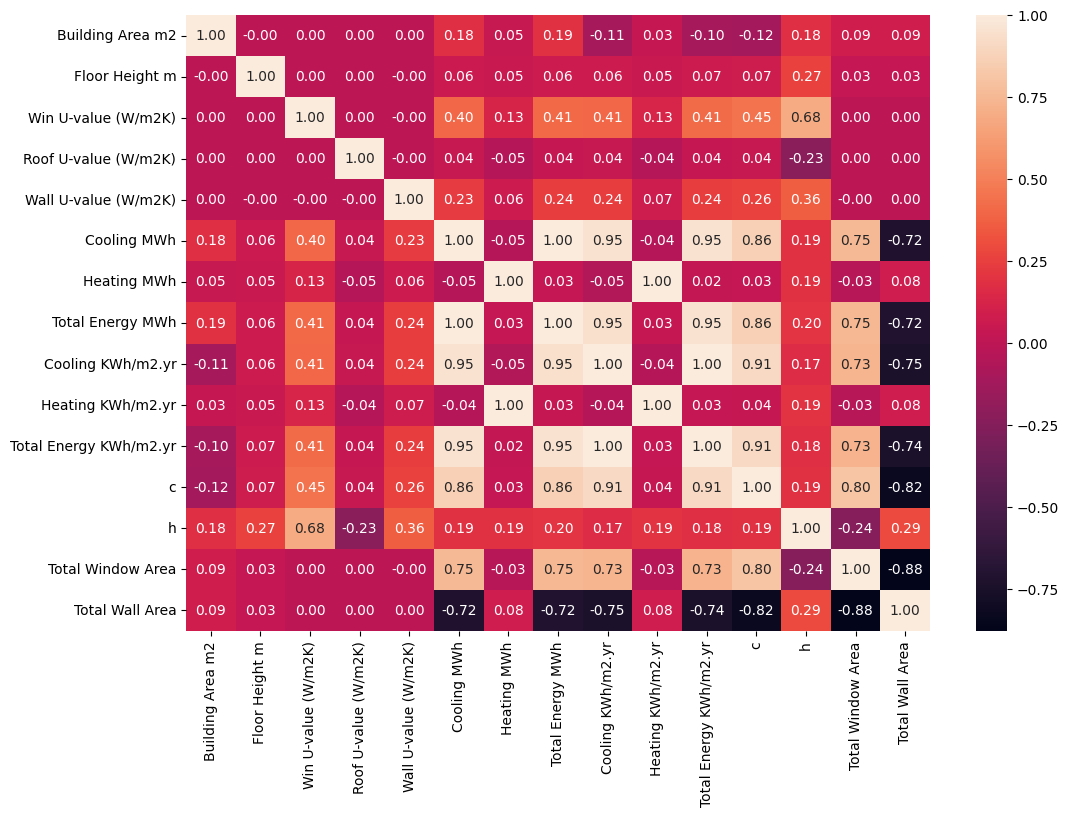

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize distributions
sns.pairplot(data_cleaned)
plt.show()

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data_cleaned.corr(), annot=True, fmt='.2f')
plt.show()

In [29]:
# Feature Engineering 
data_cleaned['Total Window Area'] = data_cleaned['Exterior Win Area'] * data_cleaned['WWR %\n = 10-90% of Exterior Win (D) from Opaque Wall (E)'] / 100
data_cleaned['Total Wall Area'] = data_cleaned['Opaque Exterior Wall Area'] * (1 - data_cleaned['WWR %\n = 10-90% of Exterior Win (D) from Opaque Wall (E)'] / 100)

# Drop 
data_cleaned = data_cleaned.drop(columns=['Exterior Win Area', 'WWR %\n = 10-90% of Exterior Win (D) from Opaque Wall (E)', 'Opaque Exterior Wall Area'])


In [30]:

X = data_cleaned.drop(columns=['Total Energy MWh'])  # Replace with the actual target variable if different
y = data_cleaned['Total Energy MWh']  # Replace with the actual target variable if different


In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
# ANN model
model = Sequential()

# Input layer and first hidden layer
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer
model.add(Dense(units=32, activation='relu'))

# Output layer
model.add(Dense(units=1))


D:\ml ENN\my_venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')


In [34]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)


Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 756.3057 - val_loss: 53.3231
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45.4086 - val_loss: 32.9793
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.7852 - val_loss: 25.2760
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 22.2624 - val_loss: 20.3582
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.7393 - val_loss: 16.9919
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.3360 - val_loss: 14.0617
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.8862 - val_loss: 12.6040
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.7111 - val_loss: 8.8647
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.8949 - val_loss: 6.8251
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0642 - val_loss: 5.1416
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4239 - val_loss: 4.1435
Epoch 12/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

In [35]:
# Make predictions
y_pred_ann = model.predict(X_test)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [36]:
# Evaluate the model
mae_ann = mean_absolute_error(y_test, y_pred_ann)
mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = mean_squared_error(y_test, y_pred_ann, squared=False)

print(f'ANN Mean Absolute Error: {mae_ann}')
print(f'ANN Mean Squared Error: {mse_ann}')
print(f'ANN Root Mean Squared Error: {rmse_ann}')


ANN Mean Absolute Error: 0.35441031575004267
ANN Mean Squared Error: 0.19203254548789392
ANN Root Mean Squared Error: 0.4382151817177195


D:\ml ENN\my_venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


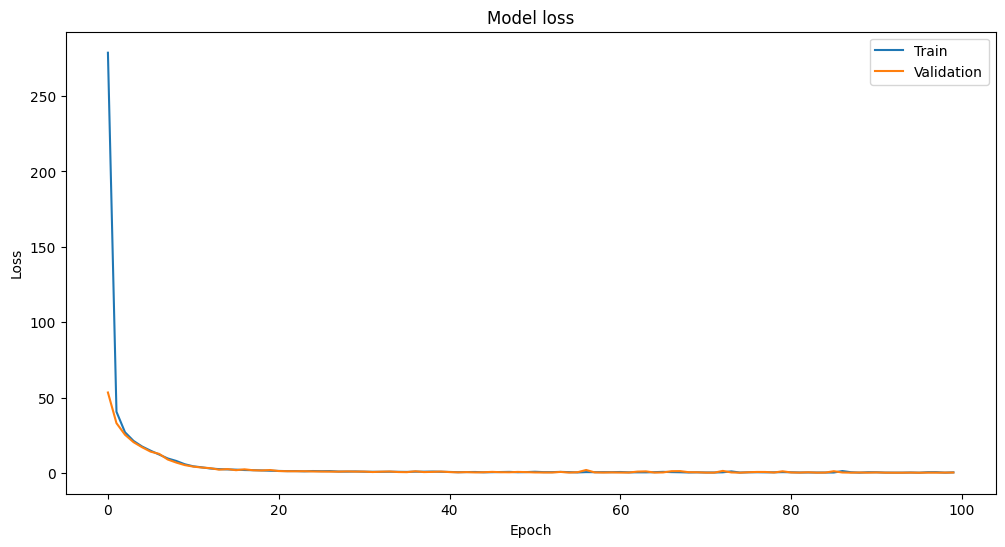

In [41]:
# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


In [38]:

model.save('energy_consumption_ann_model.h5')
